### import

In [37]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [38]:
df = pd.DataFrame({
    'A': [np.nan, 2, 3, 4, 5],
    'B': [10, 20, 30, np.nan, 50],
    'C': [100, np.nan, 300, 400, 500],
    'D': [1000, 2000, 3000, np.nan, 5000]
})
df

,A,B,C,D
0,NaN,10.0,100.0,1000.0
1,2.0,20.0,NaN,2000.0
2,3.0,30.0,300.0,3000.0
3,4.0,NaN,400.0,NaN
4,5.0,50.0,500.0,5000.0


### initial look at the data

In [39]:
df.head() # first 5 rows
df.head(10) # first 10 rows
df.tail() # last 5 rows
df.shape # number of rows and columns
df.info() # information about the dataframe
df.describe() # statistical summary of the dataframe
df.columns # list of column names
df.index # index of the dataframe

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       4 non-null      float64
 1   B       4 non-null      float64
 2   C       4 non-null      float64
 3   D       4 non-null      float64
dtypes: float64(4)
memory usage: 292.0 bytes


RangeIndex(start=0, stop=5, step=1)

### checking for missing values

In [40]:
df.isnull() # check for missing values

,A,B,C,D
0,True,False,False,False
1,False,False,True,False
2,False,False,False,False
3,False,True,False,True
4,False,False,False,False


In [41]:
df.isnull().sum() # count of null values in each column

A    1
B    1
C    1
D    1
dtype: int64

In [42]:
df.dropna() # drop rows with missing values

,A,B,C,D
2,3.0,30.0,300.0,3000.0
4,5.0,50.0,500.0,5000.0


In [43]:
df.fillna(0) # fill missing values with 0

,A,B,C,D
0,0.0,10.0,100.0,1000.0
1,2.0,20.0,0.0,2000.0
2,3.0,30.0,300.0,3000.0
3,4.0,0.0,400.0,0.0
4,5.0,50.0,500.0,5000.0


In [44]:
# fill missing values in dataframe with the mean of
df.fillna(df.mean())

,A,B,C,D
0,3.5,10.0,100.0,1000.0
1,2.0,20.0,325.0,2000.0
2,3.0,30.0,300.0,3000.0
3,4.0,27.5,400.0,2750.0
4,5.0,50.0,500.0,5000.0


In [45]:
# fill missing values in column A with the mean of column A
df['A'].fillna(df['A'].mean())

0    3.5
1    2.0
2    3.0
3    4.0
4    5.0
Name: A, dtype: float64

### categorical columns

In [46]:
df['A'].value_counts() # count of unique values in column A

A
2.0    1
3.0    1
4.0    1
5.0    1
Name: count, dtype: int64

In [47]:
df['A'].unique() # unique values in column A

array([nan,  2.,  3.,  4.,  5.])

In [48]:
df['A'].nunique() # number of unique values in column A

4

### relationship of a column with target

In [50]:
# group by column A and calculate the mean of column B for each group
df.groupby('A')['B'].mean()

A
2.0    20.0
3.0    30.0
4.0     NaN
5.0    50.0
Name: B, dtype: float64

In [52]:
# group by column A and calculate the mean and count of column B for each group
df.groupby('A')['B'].agg(['mean', 'count'])

,mean,count
A,,
2.0,20.0,1
3.0,30.0,1
4.0,NaN,0
5.0,50.0,1


### drawing a simple graph

<Axes: >

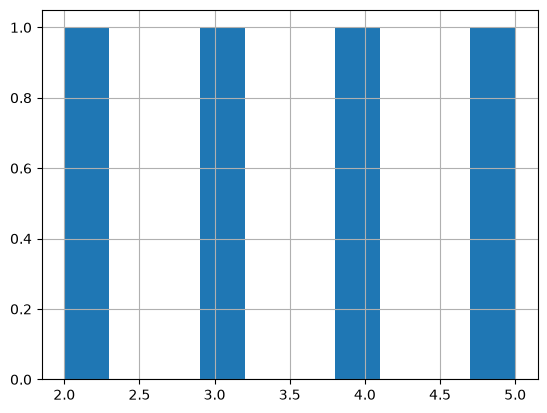

In [53]:
df['A'].hist()

<Axes: >

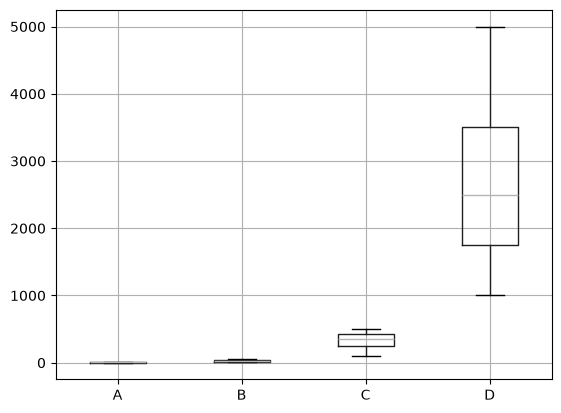

In [ ]:
df.boxplot()

<Axes: >

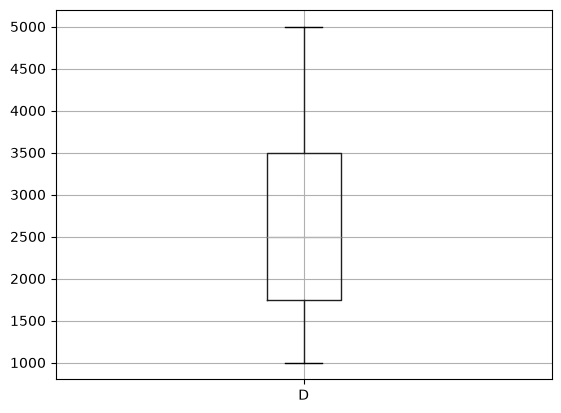

In [55]:
df.boxplot(column= 'D')

A simple summary:

EDA means asking your data these three questions before building a model:

1. What does my data look like? (Size, type, missing values)
2. Which columns are related to my target ?
3. Are there any anomalies (outliers, errors)?